<a href="https://colab.research.google.com/github/ranjit0606/Artificial-Intelligence-and-its-Real-time-Applications-using-Python/blob/main/2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#2-3



In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [ ]:
from spacy.matcher import Matcher
matcher = Matcher(nlp.vocab)

In [ ]:
pattern1 = [{'LOWER':'solarpower'}]
pattern2 = [{'LOWER':'solar'},{'LOWER':'power'}]
pattern3=[{'LOWER':'solar'},{'IS_PUNCT':True},{'LOWER':'power'}]

In [ ]:
matcher.add('SolarPower',[pattern1,pattern2,pattern3])

In [ ]:
doc=nlp(u'the solar power industry continues to grow demand for solarpower increases solar-power cars are gaining popularity.')

In [ ]:
found_matches = matcher(doc)
print(found_matches)

[(8656102463236116519, 1, 3), (8656102463236116519, 9, 10), (8656102463236116519, 11, 14)]


In [ ]:
from IPython.utils.text import string
for match_id,start,end in found_matches:
  string_id = nlp.vocab.strings[match_id]
  span = doc[start:end]
  print(match_id,string_id,start,end,span.text)

8656102463236116519 SolarPower 1 3 solar power
8656102463236116519 SolarPower 9 10 solarpower
8656102463236116519 SolarPower 11 14 solar-power


In [ ]:
doc2 = nlp(u'solar-power cars are gaining popularity.')

In [ ]:
found_matches = matcher(doc2)
print(found_matches)

[(8656102463236116519, 0, 3)]


In [ ]:
matcher.remove('SolarPower')

In [ ]:
pattern4=[{'LOWER':'Solar'},{'IS_PUNCT':True,'OP':'*'},{'LOWER':'powered'}]
matcher.add('SolarPower',[pattern1,pattern2,pattern3,pattern4])

In [ ]:
found_matches = matcher(doc)
print(found_matches)

[(8656102463236116519, 1, 3), (8656102463236116519, 9, 10), (8656102463236116519, 11, 14)]


In [ ]:
pwd

'/content'

In [ ]:
with open('/content/reaganomics.txt') as f:
  doc3 = nlp(f.read())

In [ ]:
phrase_list = ['voodoo economics','supply-side economics','trickle-down economics','free-market economics']
phrase_patterns_docs = [nlp(text) for text in phrase_list]

# Convert Doc objects into lists of token patterns for the Matcher
patterns_for_matcher = []
for doc_pattern in phrase_patterns_docs:
  token_pattern = [{'LOWER': token.lower_} for token in doc_pattern]
  patterns_for_matcher.append(token_pattern)

matcher.add('VoodooEconomics', patterns_for_matcher)
matches=matcher(doc3)

In [ ]:
matches

[(3473369816841043438, 23, 27),
 (3473369816841043438, 32, 36),
 (3473369816841043438, 37, 39)]

In [ ]:
doc3[:45]

The economic policies promoted by U.S. President Ronald Reagan during the 1980s are known as Reaganomics. These policies are commonly associated with supply-side economics, also referred to as trickle-down economics or voodoo economics by political opponents, and free

In [ ]:
doc3[1:]

economic policies promoted by U.S. President Ronald Reagan during the 1980s are known as Reaganomics. These policies are commonly associated with supply-side economics, also referred to as trickle-down economics or voodoo economics by political opponents, and free-market capitalism.

In [ ]:
sents = [sent for sent in doc3.sents]
print(sents[0].start,sents[0].end)

0 17


In [ ]:
for sent in sents:
  if matches[0][1]<sent.end:
    print(sent)
    break

These policies are commonly associated with supply-side economics, also referred to as trickle-down economics or voodoo economics by political opponents, and free-market capitalism.


#day 2-4


In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [ ]:
doc=nlp(u'the quick brown for jumper over the lazy dogs back.')
print(doc.text)

the quick brown for jumper over the lazy dogs back.


In [ ]:
print(doc[4].text,doc[4].pos_,doc[4].tag_,spacy.explain(doc[4].tag_))

jumper NOUN NN noun, singular or mass


In [ ]:
for token in doc:
  print(f"{token.text:{10}}{token.pos_:{8}}{token.tag_:{6}}{spacy.explain(token.tag_)}")

the       DET     DT    determiner
quick     ADJ     JJ    adjective (English), other noun-modifier (Chinese)
brown     NOUN    NN    noun, singular or mass
for       ADP     IN    conjunction, subordinating or preposition
jumper    NOUN    NN    noun, singular or mass
over      ADP     IN    conjunction, subordinating or preposition
the       DET     DT    determiner
lazy      ADJ     JJ    adjective (English), other noun-modifier (Chinese)
dogs      NOUN    NNS   noun, plural
back      ADV     RB    adverb
.         PUNCT   .     punctuation mark, sentence closer


In [ ]:
doc= nlp(u'i need books on nlp')
r=doc[1]
print(f'{r.text:{10}} {r.pos_:{8}} {r.tag_:{6}} {spacy.explain(r.tag_)}')

need       VERB     VBP    verb, non-3rd person singular present


In [ ]:
doc = nlp(u'i read a book on nlp')
r=doc[1]
print(f'{r.text:{10}} {r.pos_:{8}} {r.tag_:{6}} {spacy.explain(r.tag_)}')

read       VERB     VBD    verb, past tense


In [ ]:
Dep_Counts = doc.count_by(spacy.attrs.DEP)
for k,v in sorted(Dep_Counts.items()):
  print(f"{k}.{doc.vocab[k].text:{5}} {v}")


415.det   1
416.dobj  1
429.nsubj 1
439.pobj  1
443.prep  1
8206900633647566924.ROOT  1


In [ ]:
from spacy import displacy

In [ ]:
doc = nlp(u'the quick brown fox jumped over the lazy dog')
for token in doc :
  print(f'{token.text:{10}} {token.pos_:{7}} {token.dep_:{7}} {spacy.explain(token.dep_)}')

the        DET     det     determiner
quick      ADJ     amod    adjectival modifier
brown      ADJ     amod    adjectival modifier
fox        NOUN    nsubj   nominal subject
jumped     VERB    ROOT    root
over       ADP     prep    prepositional modifier
the        DET     det     determiner
lazy       ADJ     amod    adjectival modifier
dog        NOUN    pobj    object of preposition


In [ ]:
displacy.render(doc,style='dep',jupyter=True,options={'distance':110})

In [ ]:
doc2=nlp(u'this is a sentence.this is another possibility longer sentence')
spans= list(doc2.sents)
options={'distance':110,'compact':'false','color':'yellow','bg':'#09a3d5','font':'Times'}
displacy.render(doc2,style='dep',jupyter=True,options=options)

In [ ]:
def show_ents(docs):
    if docs.ents:
      for ent in docs.ents:
          print(ent.text+' - '+ent.label_+' - '+str(spacy.explain(ent.label_)))
    else:
      print('no entities found')

In [ ]:
doc = nlp(u'May i go to washington,dc next may to see the washington monuments?')
show_ents(doc)

washington - GPE - Countries, cities, states
washington - GPE - Countries, cities, states


In [ ]:
doc=nlp(u'can i please borrow 500 dollars from you to buy some microsoft stock?')
for ent in doc.ents:
  print(ent.text,ent.start,ent.end,ent.start_char,ent.end_char,ent.label_)

500 dollars 4 6 20 31 MONEY


In [ ]:
doc= nlp(u'Tesla to build a U.K. factory for $6 million')
show_ents(doc)

U.K. - GPE - Countries, cities, states
$6 million - MONEY - Monetary values, including unit


In [ ]:
doc= nlp(u'Tesla to build a U.K. factory for $6 million')
ORG= doc.vocab.strings[u'ORG']
new_ent = spacy.tokens.Span(doc,0,1,label=ORG)
doc.ents = list(doc.ents) + [new_ent]
show_ents(doc)

Tesla - ORG - Companies, agencies, institutions, etc.
U.K. - GPE - Countries, cities, states
$6 million - MONEY - Monetary values, including unit


In [ ]:
doc = nlp(u'our company plans to introduce a new vacuum cleaner.if successful,the vacuum cleaner will be our first product.')
show_ents(doc)

first - ORDINAL - "first", "second", etc.


In [ ]:
from spacy.matcher import PhraseMatcher
matcher = PhraseMatcher(nlp.vocab)

In [ ]:
doc=nlp(u'our company plans to introduce a new vacuum cleaner')
phrase_list = ['vacuum cleaner','vacuum-cleaner']
phrase_patterns = [nlp(text) for text in phrase_list]
matcher.add('newproduct',None,*phrase_patterns)
matches = matcher(doc)
matches

[(2689272359382549672, 7, 9)]

#2-5

In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [ ]:
doc = nlp(u'this is the first sentence.this is the another sentence.this is the last sentence')
for sent in doc.sents:
  print(sent)

this is the first sentence.this is the another sentence.this is the last sentence


In [ ]:
print(doc[1])

is


In [ ]:
sentences = list(doc.sents)
print(sentences[0])

this is the first sentence.this is the another sentence.this is the last sentence


In [ ]:
doc_sents = [sent for sent in doc.sents]
doc_sents

[this is the first sentence.this is the another sentence.this is the last sentence]

In [ ]:
print(doc_sents[0])

this is the first sentence.this is the another sentence.this is the last sentence


In [ ]:
doc2 = nlp(u'this is the first sentence.this is the another sentence.this is a sentence')
for token in doc2:
  print(token.is_sent_start,' '+token.text)

True  this
False  is
False  the
False  first
False  sentence.this
False  is
False  the
False  another
False  sentence.this
False  is
False  a
False  sentence


In [ ]:
doc2 = nlp(u'this is the first sentence.this is the another sentence.this is a sentence')
for token in doc2:
  print(token.is_sent_end,' '+token.text)

False  this
False  is
False  the
False  first
False  sentence.this
False  is
False  the
False  another
False  sentence.this
False  is
False  a
True  sentence


In [ ]:
doc= nlp(u'"management is doing the right things;leadership is doing the right things." -Peter Ducker')
for sent in doc.sents:
  print(sent)
  print('\n')

"management is doing the right things;leadership is doing the right things."


-Peter Ducker




In [ ]:
doc

"management is doing the right things;leadership is doing the right things." -Peter Ducker

In [ ]:
doc[:-2]

"management is doing the right things;leadership is doing the right things."

In [ ]:
from spacy.language import Language
@Language.component("set_custom_boundaries")
def set_custom_boundaries(doc):
  for token in doc[:-1]:
    if token.text == ';':
      doc[token.i+1].is_sent_start = True # Correctly set sentence start
  return doc

In [ ]:
if "set_custom_boundaries" in nlp.pipe_names:
    nlp.remove_pipe("set_custom_boundaries")
nlp.add_pipe("set_custom_boundaries",before='parser')
print(nlp.pipe_names)

['tok2vec', 'tagger', 'set_custom_boundaries', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [ ]:
doc4= nlp(u'"management is doing the right things;leadership is doing the right things." -Peter Ducker')
for sent in doc4.sents:
  print(sent)


"management is doing the right things;leadership is doing the right things."
-Peter Ducker


In [ ]:
import spacy
doc4= nlp(u'"management is doing the right things;leadership is doing the right things." -Peter Ducker')
for sent in doc4.sents:
  print(sent)

"management is doing the right things;leadership is doing the right things."
-Peter Ducker


In [ ]:
doc4[4]

the

In [ ]:
nlp = spacy.load('en_core_web_sm')


In [ ]:
doc4[4].is_sent_start

False

In [ ]:
nlp = spacy.load('en_core_web_sm')
mystring = u"This is a sentence. This is another \n\n This is a \nthird sentence."
doc = nlp(mystring)
for sent in doc.sents:
  print([token.text for token in sent])

['This', 'is', 'a', 'sentence', '.']
['This', 'is', 'another', '\n\n ', 'This', 'is', 'a', '\n', 'third', 'sentence', '.']


#**2.6**

In [ ]:
 import numpy as np
 import pandas as pd


In [ ]:
df=pd.read_csv('smsspamcollection.tsv',sep='\t')

In [ ]:
df['label'].unique()

array(['ham', 'spam'], dtype=object)

In [ ]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [ ]:
df['length'].describe()

,length
count,5572.000000
mean,80.489950
std,59.942907
min,2.000000
25%,36.000000
50%,62.000000
75%,122.000000
max,910.000000


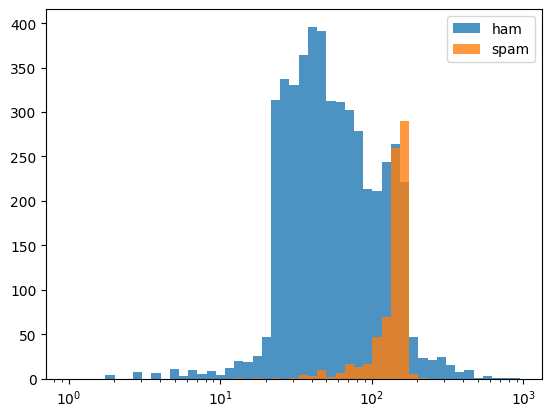

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.xscale('log')
bins=1.15**(np.arange(0,50))
plt.hist(df[df['label']=='ham']['length'],bins=bins,alpha=0.8)
plt.hist(df[df['label']=='spam']['length'],bins=bins,alpha=0.8)
plt.legend(('ham','spam'))
plt.show()

In [ ]:
df['punct'].describe()

,punct
count,5572.000000
mean,4.177495
std,4.623919
min,0.000000
25%,2.000000
50%,3.000000
75%,6.000000
max,133.000000


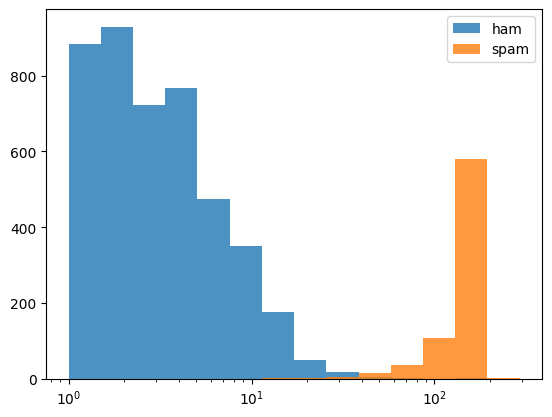

In [ ]:
plt.xscale('log')
bins= 1.5**(np.arange(0,15))
plt.hist(df[df['label']=='ham']['punct'],bins=bins,alpha=0.8)
plt.hist(df[df['label']=='spam']['length'],bins=bins,alpha=0.8)
plt.legend(('ham','spam'))
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving smsspamcollection.tsv to smsspamcollection.tsv


In [ ]:
import pandas as pd

df = pd.read_csv('smsspamcollection.tsv', sep='\t')
print(df.head())

  label                                            message  length  punct
0   ham  Go until jurong point, crazy.. Available only ...     111      9
1   ham                      Ok lar... Joking wif u oni...      29      6
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...     155      6
3   ham  U dun say so early hor... U c already then say...      49      6
4   ham  Nah I don't think he goes to usf, he lives aro...      61      2


In [ ]:
from sklearn.model_selection import train_test_split


# Features
X = df[['length', 'punct']]

# Target
y = df['label']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)

Training data shape: (3733, 2)
Testing data shape: (1839, 2)


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load data
X, y = load_iris(return_X_y=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)

# Prediction
y_pred = lr_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [ ]:
from sklearn import metrics
predictions = lr_model.predict(X_test)
print(metrics.confusion_matrix(y_test,predictions))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [27]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train,y_train)

MultinomialNB()